In [8]:
import pandas as pd
import os
import matplotlib.pyplot as plt

In [2]:
# Load the dataset
with open('../data/latest_timestamp.txt', 'r') as f:
    latest_timestamp = f.read().strip()

file_path = f'../data/processed/cleaned_movies_{latest_timestamp}.parquet'
df = pd.read_parquet(file_path)
df.head()

,id,title,tagline,release_date,genres,belongs_to_collection,original_language,budget_musd,revenue_musd,production_companies,...,vote_average,popularity,runtime,overview,spoken_languages,poster_path,cast,cast_size,director,crew_size
0,299534,Avengers: Endgame,Avenge the fallen.,2019-04-24,Adventure | Science Fiction | Action,The Avengers Collection,en,356.0,2799.439100,Marvel Studios,...,8.238,22.2597,181,After the devastating events of Avengers: Infi...,en | ja | xh,/ulzhLuWrPK07P1YkdWQLZnQh1JL.jpg,"Robert Downey Jr., Chris Evans, Mark Ruffalo, ...",105,"Anthony Russo, Joe Russo",593
1,19995,Avatar,Enter the world of Pandora.,2009-12-15,Action | Adventure | Fantasy | Science Fiction,Avatar Collection,en,237.0,2923.706026,Dune Entertainment | Lightstorm Entertainment ...,...,7.588,31.3525,162,"In the 22nd century, a paraplegic Marine is di...",en | es,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,"Sam Worthington, Zoe Saldaña, Sigourney Weaver...",65,James Cameron,986
2,140607,Star Wars: The Force Awakens,Every generation has a story.,2015-12-15,Adventure | Action | Science Fiction,Star Wars Collection,en,245.0,2068.223624,Lucasfilm Ltd. | Bad Robot,...,7.262,12.7841,136,Thirty years after defeating the Galactic Empi...,en,/wqnLdwVXoBjKibFRR5U3y0aDUhs.jpg,"Harrison Ford, Mark Hamill, Carrie Fisher, Ada...",182,J.J. Abrams,257
3,299536,Avengers: Infinity War,Destiny arrives all the same.,2018-04-25,Adventure | Action | Science Fiction,The Avengers Collection,en,300.0,2052.415039,Marvel Studios,...,8.236,32.6907,149,As the Avengers and their allies have continue...,en | xh,/7WsyChQLEftFiDOVTGkv3hFpyyt.jpg,"Robert Downey Jr., Chris Evans, Chris Hemswort...",69,"Anthony Russo, Joe Russo",724
4,597,Titanic,Nothing on Earth could come between them.,1997-11-18,Drama | Romance,NaN,en,200.0,2264.162353,Paramount Pictures | 20th Century Fox | Lights...,...,7.905,31.6333,194,101-year-old Rose DeWitt Bukater tells the sto...,en | fr | de | sv | it | ru,/9xjZS2rlVxm8SFx8kPC3aIGCOYQ.jpg,"Leonardo DiCaprio, Kate Winslet, Billy Zane, K...",116,James Cameron,258


In [ ]:
def create_visualization(df, analysis_results, output_dir="reports/figures"):
    """Generate and save visualizations for movie analysis results."""

    # os.makedirs(output_dir, exist_ok=True)

    # # Revenue vs Budget trends 
    # plt.figure(figsize=(10, 6))
    # plt.scatter(df['budget'], df['revenue'], alpha=0.5, c='blue', edgecolors='w', s=100)
    # plt.xlabel('Budget $M')
    # plt.ylabel('Revenue $M')
    # plt.title('Revenue vs Budget Trends')
    # plt.grid(True, linestyle='--', alpha=0.7)
    # plt.savefig(os.path.join(output_dir, 'revenue_vs_budget.png'), dpi=300, bbox_inches='tight')
    # plt.close()

    # ROI Distribution by Genre
    genres = df['genres'].str.split(' | ', expand=True).stack().unique()
    roi_by_genre = {
        genre: df[df['genres'].str.contains(genres, na=False)]['roi'].dropna()
        for genre in genres if genre
    }
    

In [11]:
def revenue_budget_trends(df, output_dir="reports/figures"):
    os.makedirs(output_dir, exist_ok=True)
    plt.figure(figsize=(10, 6))
    plt.scatter(df['budget_musd'], df['revenue_musd'], alpha=0.5, c='blue', edgecolors='w', s=100)
    plt.xlabel('Budget $M')
    plt.ylabel('Revenue $M')
    plt.title('Revenue vs Budget Trends')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.savefig(os.path.join(output_dir, 'revenue_vs_budget.png'), dpi=300, bbox_inches='tight')
    plt.show()

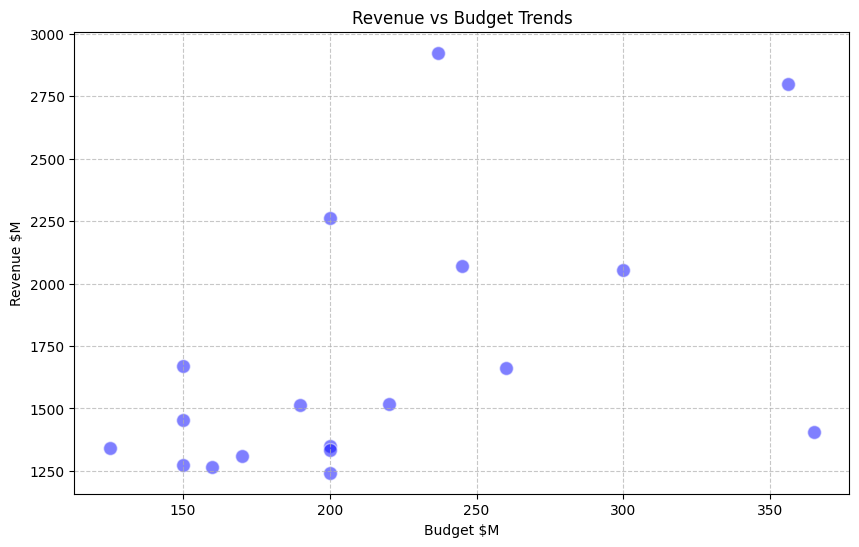

In [12]:
revenue_budget_trends(df)

In [13]:
def roi_distribution_by_genre(df, output_dir="reports/figures"):
    os.makedirs(output_dir, exist_ok=True)
    genres = df['genres'].str.split(' | ', expand=True).stack().unique()
    roi_by_genre = {
        genre: df[df['genres'].str.contains(genre, na=False)]['roi'].dropna()
        for genre in genres if genre
    }
    plt.figure(figsize=(12, 8))
    for genre, roi in roi_by_genre.items():
        plt.hist(roi, bins=30, alpha=0.5, label=genre)
    plt.xlabel('ROI')
    plt.ylabel('Frequency')
    plt.title('ROI Distribution by Genre')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.savefig(os.path.join(output_dir, 'roi_distribution_by_genre.png'), dpi=300, bbox_inches='tight')
    plt.show()

In [14]:
roi_distribution_by_genre(df)

KeyError: 'roi'